In [1]:
from torch.distributions import Poisson, Normal, MultivariateNormal
from gpzoo.gp import SVGP, MGGP_SVGP, VNNGP, MGGP_WSVGP, MGGP_VNNGP
from gpzoo.kernels import batched_RBF, batched_MGGP_RBF
from gpzoo.utilities import build_sparse_from_Kzx_knnidx, symmetrize_by_copy, add_jitter, init_Lu
import torch
import matplotlib.pyplot as plt

/gladstone/engelhardt/home/lchumpitaz/gitclones/GPzoo/gpzoo/utilities.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
torch.manual_seed(12)

In [3]:
N = 30

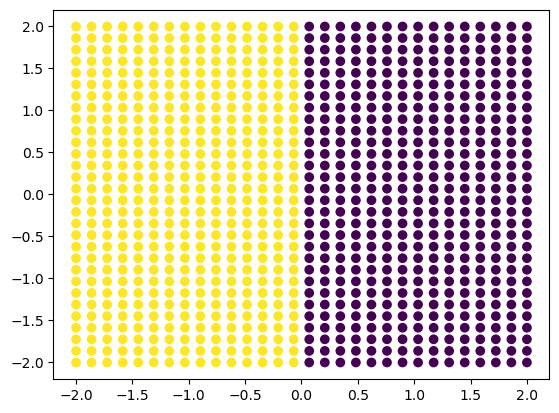

In [4]:
# Define the grid range and resolution
grid_size = N  # Number of points per dimension
x1 = torch.linspace(-2, 2, grid_size)
x2 = torch.linspace(-2, 2, grid_size)

# Create a meshgrid
x1, x2 = torch.meshgrid(x1, x2, indexing="ij")

# Stack to get a grid of shape (grid_size * grid_size, 2)
X = torch.stack([x1.flatten(), x2.flatten()], dim=1)

groupsX = (X[:,0] < 0).type(torch.long) 
plt.scatter(X[:, 0], X[:, 1], c=groupsX)


In [5]:
len(X)

900

In [6]:
K= 50
n_groups = 2


group_diff_params = [1e-2, 1e-1, 1e0, 1e1]

Ws = []

for group_diff_param in group_diff_params:

    M = N**2
    
    Z = X[::2]
    groupsZ = groupsX[::2]
    
    kernel = batched_MGGP_RBF(sigma=1.0, lengthscale=0.8, group_diff_param=group_diff_param, n_groups=2)
    
    
    W = init_Lu(kernel, X, groupsX, Z, groupsZ, K)
    
    gp = MGGP_VNNGP(kernel, dim=1, M=M, n_groups=n_groups, jitter=1e-5, K=K)
    
    gp.Z = torch.nn.Parameter(X)
    gp.groupsZ = torch.nn.Parameter( groupsX, requires_grad=False)
    gp.mu = torch.nn.Parameter(torch.zeros(2*N))
    
    knn_idx = gp.calculate_knn(X)
    gp.knn_idx = knn_idx[:, :-1]
    gp.knn_idz= knn_idx[:, 1:]
    
    
    gp.Lu = torch.nn.Parameter(W)
    Ws.append(W)

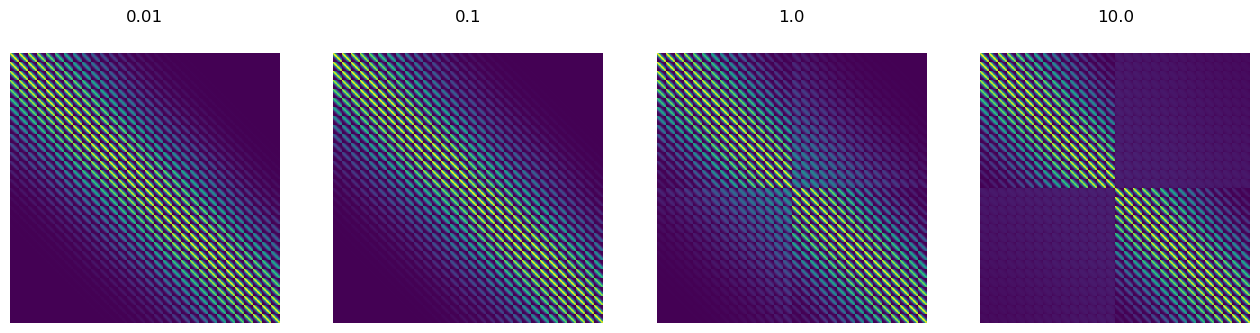

In [7]:
fig = plt.figure(figsize=(16,4 ))
for i in range(4):
    ax = fig.add_subplot(1, 4, i+1)
    ax.matshow((Ws[i]@Ws[i].T).detach(), vmin=0, vmax=1)
    ax.set_axis_off()
    ax.set_title(group_diff_params[i])


In [8]:
T = 120

all_samples = []


for i in range(4):
    samples = []
    for t in range(0, T):
        pi_range = torch.linspace(-1, 1, K)*torch.pi
        value = pi_range+ (t*2*torch.pi/T)
        
        sample = (Ws[i][:, :K]@torch.sin(2*value)).detach()
        samples.append(sample)
        
    all_samples.append(samples)

# sample = (W@torch.randn(K)).detach()


In [9]:
all_samples[i][0].shape

torch.Size([900])

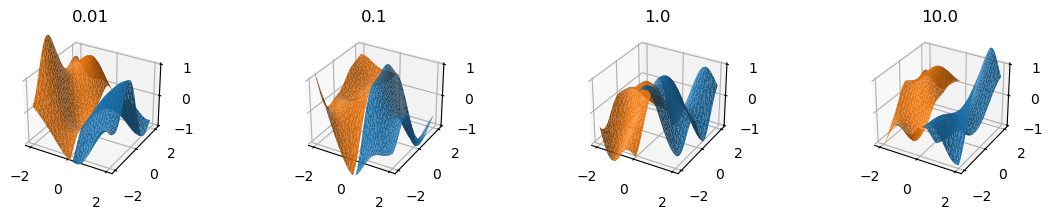

In [10]:
fig, ax = plt.subplots(1, 4, figsize=(14,2), subplot_kw={'projection': '3d'})
from mpl_toolkits.mplot3d import axes3d


for i in range(4):

    for j in range(2):
        mask = groupsX==j
        ax[i].plot_trisurf(X[mask, 0], X[mask, 1], Z=all_samples[i][0][mask])
        
    ax[i].set_title(group_diff_params[i])
    ax[i].set_zlim([-1,1])
    




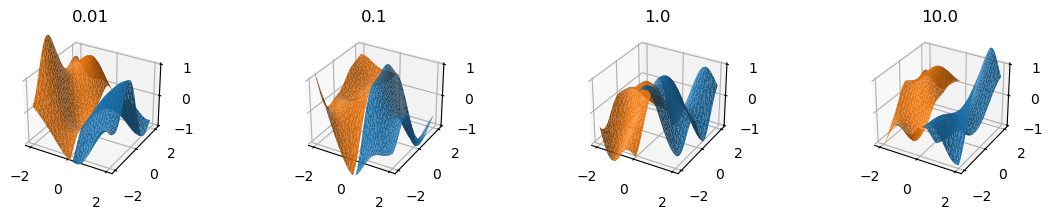

In [11]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
from tqdm import tqdm

fig, ax = plt.subplots(1, 4, figsize=(14,2), subplot_kw={'projection': '3d'})
from mpl_toolkits.mplot3d import axes3d


def update(iteration):

    for i in range(4):
        ax[i].cla()
        curr_sample = all_samples[i][iteration]
        for j in range(2):
            mask = groupsX==j
            ax[i].plot_trisurf(X[mask, 0], X[mask, 1], Z=curr_sample[mask])
            
        ax[i].set_title(group_diff_params[i])
        ax[i].set_zlim([-1,1])
            

#     fig.suptitle(f"Iteration: {iteration}, Loss: {losses[iteration*10]:0.2f}")
#     fig.tight_layout()

anim = FuncAnimation(fig, update, frames=np.arange(0, 120, 1), interval=100)
# anim.save('pnmf.mp4',
#          writer=animation.FFMpegWriter(fps=50, bitrate=2000, codec='h264'),
#          dpi=50)
anim.save('mggp_test_multiple_2D.gif', fps=20, dpi=100)

In [12]:
# Define the grid range and resolution
grid_size = N  # Number of points per dimension
x1 = torch.linspace(-2, 2, grid_size)
x2 = torch.linspace(-2, 2, grid_size)

# Create a meshgrid
x1, x2 = torch.meshgrid(x1, x2, indexing="ij")

# Stack to get a grid of shape (grid_size * grid_size, 2)
X1 = torch.stack([x1.flatten(), x2.flatten()], dim=1)
groupsX1 = torch.zeros_like(X1[:,0].squeeze()).type(torch.long)
X2 = X1
groupsX2 = torch.ones_like(X2[:,0].squeeze()).type(torch.long)
X = torch.cat((X1, X2))
groupsX = torch.cat((groupsX1, groupsX2)).squeeze().type(torch.long)

In [13]:
groupsX

tensor([0, 0, 0,  ..., 1, 1, 1])

In [373]:
K= 100
n_groups = 2


group_diff_params = [1e-2, 1e-1, 1e0, 1e1]

Ws = []

for group_diff_param in group_diff_params:

    M = 2*(N**2)
    
    Z = X
    groupsZ = groupsX
    
    kernel = batched_MGGP_RBF(sigma=1.0, lengthscale=0.8, group_diff_param=group_diff_param, n_groups=2)
    
    
    W = init_Lu(kernel, X, groupsX, Z, groupsZ, K)
    
    gp = MGGP_VNNGP(kernel, dim=1, M=M, n_groups=n_groups, jitter=1e-5, K=K)
    
    gp.Z = torch.nn.Parameter(X)
    gp.groupsZ = torch.nn.Parameter( groupsX, requires_grad=False)
    gp.mu = torch.nn.Parameter(torch.zeros(2*N))
    
    knn_idx = gp.calculate_knn(X)
    gp.knn_idx = knn_idx[:, :-1]
    gp.knn_idz= knn_idx[:, 1:]
    
    
    gp.Lu = torch.nn.Parameter(W)
    Ws.append(W)

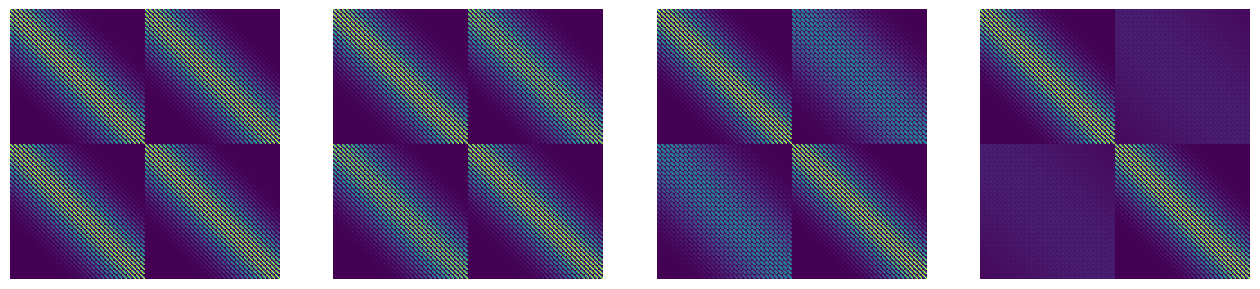

In [374]:
fig = plt.figure(figsize=(16, 4))
for i in range(4):
    ax = fig.add_subplot(1, 4, i+1)
    ax.matshow((Ws[i]@Ws[i].T).detach(), vmin=0, vmax=1)
    ax.set_axis_off()
    # ax.set_title(group_diff_params[i])


In [375]:
(Ws[i]@Ws[i].T).detach().diag()

tensor([0.9961, 0.9987, 0.9987,  ..., 0.9987, 0.9987, 0.9961])

In [376]:
T = 120

all_samples = []


for i in range(4):
    samples = []
    for t in range(0, T):
        pi_range = torch.linspace(-1, 1, K)*torch.pi
        value = pi_range+ (t*2*torch.pi/T)
        
        sample = (Ws[i][:, :K]@torch.sin(2*value)).detach()
        samples.append(sample)
        
    all_samples.append(samples)

# sample = (W@torch.randn(K)).detach()


In [377]:
sample.shape

torch.Size([1800])

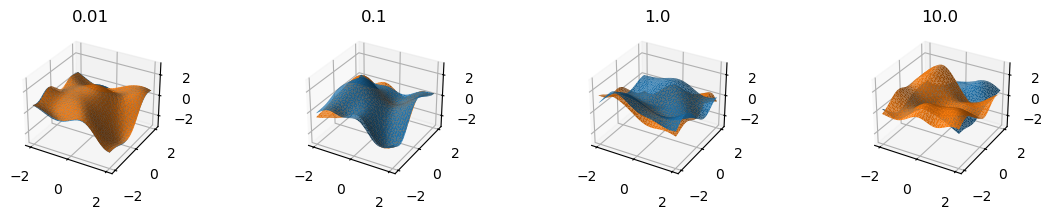

In [378]:
fig, ax = plt.subplots(1, 4, figsize=(14,2), subplot_kw={'projection': '3d'})
from mpl_toolkits.mplot3d import axes3d


for i in range(4):

    for j in range(2):
        mask = groupsX==j
        ax[i].plot_trisurf(X[mask, 0], X[mask, 1], Z=all_samples[i][97][mask])
        
    ax[i].set_title(group_diff_params[i])
    ax[i].set_zlim([-3.0,3.0])
    




/tmp/ipykernel_973379/1071708157.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


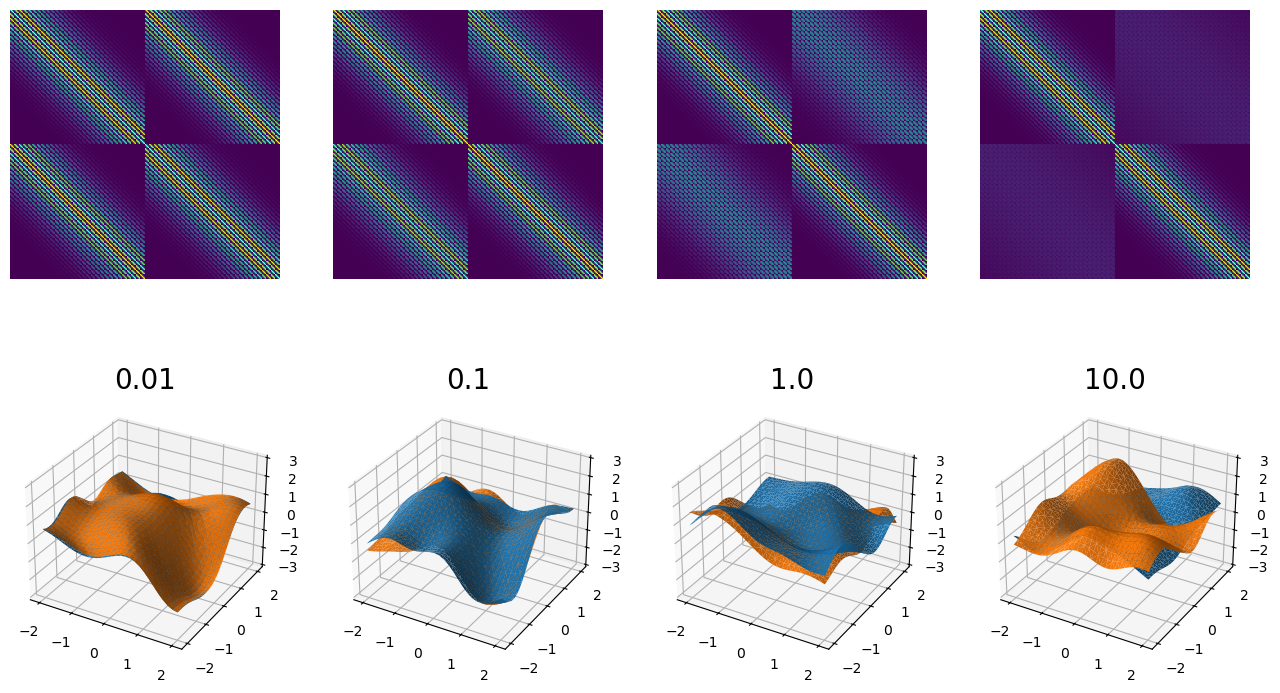

In [379]:
fig = plt.figure(figsize=(16, 10))  # taller for both rows
from mpl_toolkits.mplot3d import axes3d

import matplotlib.gridspec as gridspec

# Create a 2×4 grid (2 rows, 4 columns)
gs = gridspec.GridSpec(2, 4, height_ratios=[2, 2])  # top smaller, bottom larger
gs.update(wspace=0.2, hspace=0.01)  # spacing between subplots

# ---- TOP ROW: matrix plots ----
for i in range(4):
    ax = fig.add_subplot(gs[0, i])
    ax.matshow((Ws[i] @ Ws[i].T).detach(), vmin=0, vmax=1)
    ax.set_axis_off()
    # ax.set_title(f"{group_diff_params[i]}", fontsize=10, pad=2)

# ---- BOTTOM ROW: 3D plots ----
for i in range(4):
    ax = fig.add_subplot(gs[1, i], projection='3d')
    for j in range(2):
        mask = groupsX == j
        ax.plot_trisurf(X[mask, 0], X[mask, 1], Z=all_samples[i][97][mask], linewidth=0.1)
    ax.set_zlim([-3.0, 3.0])
    ax.set_title(f"{group_diff_params[i]}", fontsize=20)
    # ax.set_xticks([])
    # ax.set_yticks([])
    # ax.set_zticks([])


    

plt.tight_layout()
plt.show()

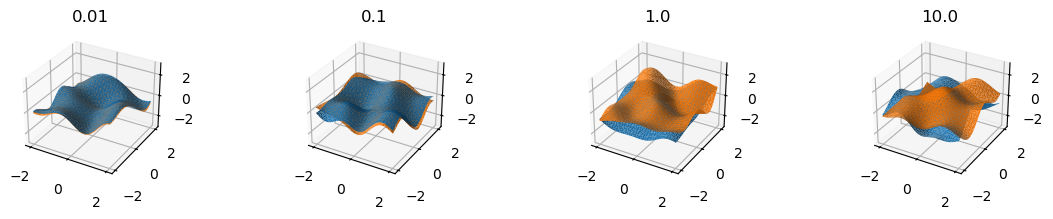

In [381]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
from tqdm import tqdm

fig, ax = plt.subplots(1, 4, figsize=(14,2), subplot_kw={'projection': '3d'})
from mpl_toolkits.mplot3d import axes3d


def update(iteration):

    for i in range(4):
        ax[i].cla()
        curr_sample = all_samples[i][iteration]
        for j in range(2):
            mask = groupsX==j
            ax[i].plot_trisurf(X[mask, 0], X[mask, 1], Z=curr_sample[mask])
            
        ax[i].set_title(group_diff_params[i])
        ax[i].set_zlim([-3.0, 3.0])
            

#     fig.suptitle(f"Iteration: {iteration}, Loss: {losses[iteration*10]:0.2f}")
#     fig.tight_layout()

anim = FuncAnimation(fig, update, frames=np.arange(0, 120, 1), interval=100)
# anim.save('pnmf.mp4',
#          writer=animation.FFMpegWriter(fps=50, bitrate=2000, codec='h264'),
#          dpi=50)
anim.save('mggp_test_multiple_2D_full.gif', fps=20, dpi=100)

In [397]:
K= 400
n_groups = 2


group_diff_params = [1e-2, 1e-1, 1e0, 1e1]

Ws = []
As = []

for group_diff_param in group_diff_params:

    M = 2*(N**2)
    
    Z = X
    groupsZ = groupsX
    
    kernel = batched_MGGP_RBF(sigma=1.0, lengthscale=0.8, group_diff_param=group_diff_param, n_groups=2)
    
    
    
    gp = MGGP_VNNGP(kernel, dim=1, M=M, n_groups=n_groups, jitter=1e-5, K=K)
    
    gp.Z = torch.nn.Parameter(X)
    gp.groupsZ = torch.nn.Parameter( groupsX, requires_grad=False)
    gp.mu = torch.nn.Parameter(torch.zeros(2*N))
    
    knn_idx = gp.calculate_knn(X)
    gp.knn_idx = knn_idx[:, :-1]
    gp.knn_idz= knn_idx[:, 1:]
    
    
    Kxx, Kzx, Kzz = gp.forward_kernels(X, groupsX)
    A = build_sparse_from_Kzx_knnidx(Kzx, knn_idx[:,:-1], 2*(N**2))
    A = symmetrize_by_copy(A)
    A = A.to_dense()
    As.append(A)

    eigvals, eigvecs = torch.linalg.eigh(A)
    eigvals_clamped = torch.clamp(eigvals, min=0.0)
    A_pos = (eigvecs * eigvals_clamped) @ eigvecs.T


    U, S, Vt = torch.linalg.svd(A_pos)
    W = U[:,:]*(S[:]**0.5).detach()
    # W= torch.cholesky(add_jitter(A_pos, 1e-5))
    
    gp.Lu = torch.nn.Parameter(W)
    Ws.append(W)

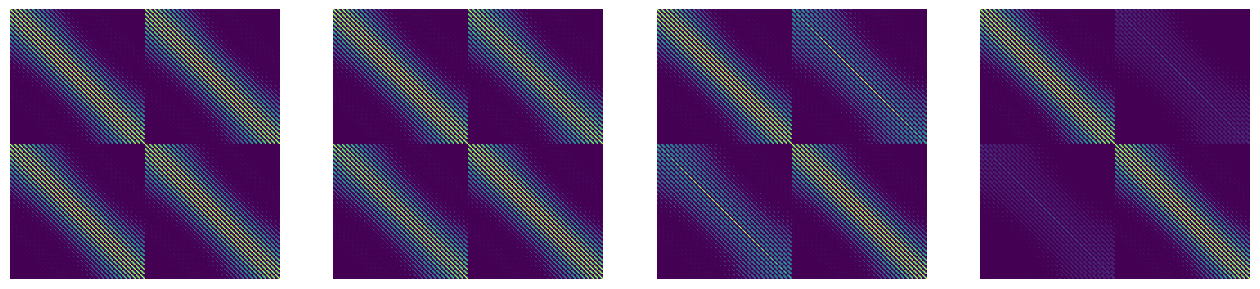

In [398]:
fig = plt.figure(figsize=(16, 4))
for i in range(4):
    ax = fig.add_subplot(1, 4, i+1)
    ax.matshow((Ws[i]@Ws[i].T).detach(), vmin=0, vmax=1)
    ax.set_axis_off()

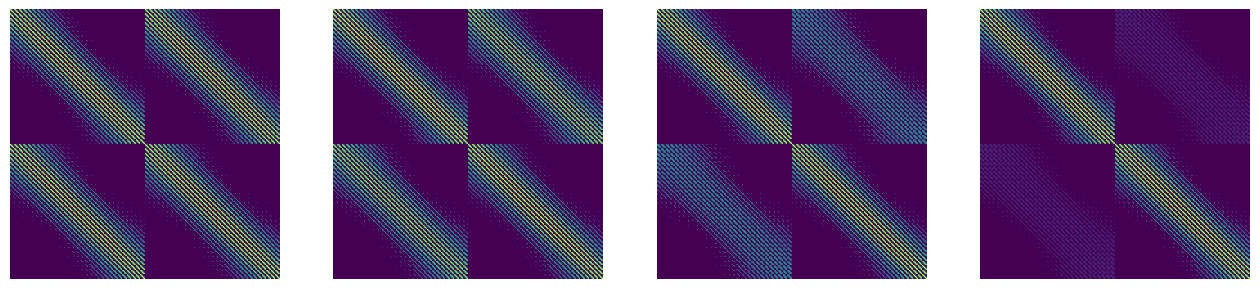

In [399]:
fig = plt.figure(figsize=(16, 4))
for i in range(4):
    ax = fig.add_subplot(1, 4, i+1)
    ax.matshow(As[i].detach(), vmin=0, vmax=1)
    ax.set_axis_off()

In [400]:
A.to_dense()

tensor([[1.0000, 0.9852, 0.9423,  ..., 0.0000, 0.0000, 0.0000],
        [0.9852, 1.0000, 0.9852,  ..., 0.0000, 0.0000, 0.0000],
        [0.9423, 0.9852, 1.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 1.0000, 0.9852, 0.9423],
        [0.0000, 0.0000, 0.0000,  ..., 0.9852, 1.0000, 0.9852],
        [0.0000, 0.0000, 0.0000,  ..., 0.9423, 0.9852, 1.0000]],
       grad_fn=<ToDenseBackward0>)

In [401]:
(Ws[i]@Ws[i].T).diag()

tensor([1.0199, 1.0213, 1.0360,  ..., 1.0375, 1.0214, 1.0204],
       grad_fn=<DiagonalBackward0_copy>)

In [402]:
S

tensor([1.4793e+02, 1.2652e+02, 1.2646e+02,  ..., 3.2300e-06, 2.4736e-06,
        8.6725e-07], grad_fn=<LinalgSvdBackward0>)

In [409]:
T = 120

all_samples = []


D = N**2

for i in range(4):
    samples = []
    for t in range(0, T):
        pi_range = torch.linspace(-1, 1, D)*torch.pi
        value = pi_range+ (t*2*torch.pi/T)
        
        sample = (Ws[i][:, :D]@torch.sin(2*value)).detach()
        samples.append(sample)
        
    all_samples.append(samples)

# sample = (W@torch.randn(K)).detach()


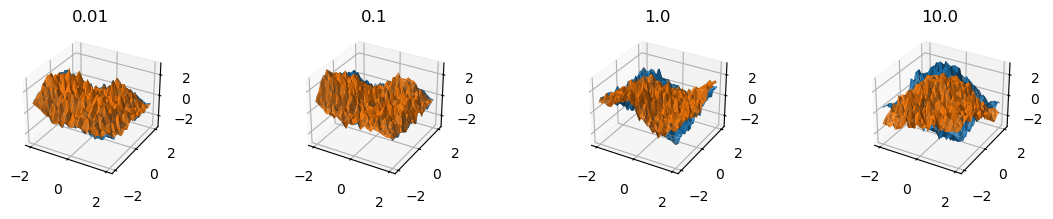

In [410]:
fig, ax = plt.subplots(1, 4, figsize=(14,2), subplot_kw={'projection': '3d'})
from mpl_toolkits.mplot3d import axes3d


for i in range(4):

    for j in range(2):
        mask = groupsX==j
        ax[i].plot_trisurf(X[mask, 0], X[mask, 1], Z=all_samples[i][110][mask])
        
    ax[i].set_title(group_diff_params[i])
    ax[i].set_zlim([-3.0,3.0])

/tmp/ipykernel_973379/1032781050.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


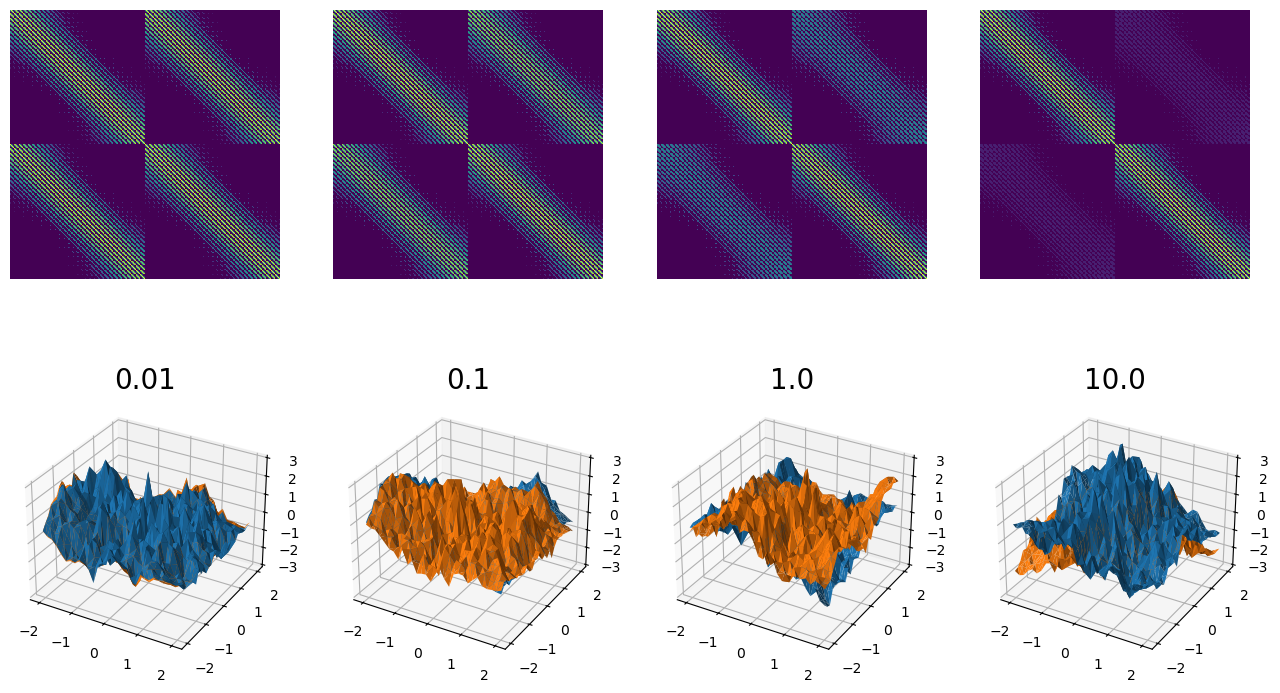

In [411]:
fig = plt.figure(figsize=(16, 10))  # taller for both rows
from mpl_toolkits.mplot3d import axes3d

import matplotlib.gridspec as gridspec

# Create a 2×4 grid (2 rows, 4 columns)
gs = gridspec.GridSpec(2, 4, height_ratios=[2, 2])  # top smaller, bottom larger
gs.update(wspace=0.2, hspace=0.01)  # spacing between subplots

# ---- TOP ROW: matrix plots ----
for i in range(4):
    ax = fig.add_subplot(gs[0, i])
    ax.matshow((As[i]).detach(), vmin=0, vmax=1)
    ax.set_axis_off()
    # ax.set_title(f"{group_diff_params[i]}", fontsize=10, pad=2)

# ---- BOTTOM ROW: 3D plots ----
for i in range(4):
    ax = fig.add_subplot(gs[1, i], projection='3d')
    for j in range(2):
        mask = groupsX == j
        ax.plot_trisurf(X[mask, 0], X[mask, 1], Z=all_samples[i][97][mask], linewidth=0.1)
    ax.set_zlim([-3.0, 3.0])
    ax.set_title(f"{group_diff_params[i]}", fontsize=20)
    # ax.set_xticks([])
    # ax.set_yticks([])
    # ax.set_zticks([])


    

plt.tight_layout()
plt.show()

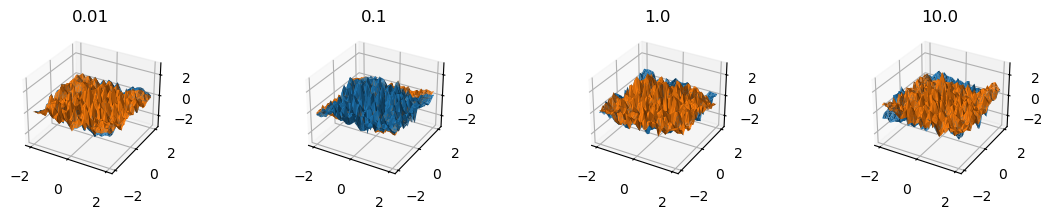

In [412]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
from tqdm import tqdm

fig, ax = plt.subplots(1, 4, figsize=(14,2), subplot_kw={'projection': '3d'})
from mpl_toolkits.mplot3d import axes3d


def update(iteration):

    for i in range(4):
        ax[i].cla()
        curr_sample = all_samples[i][iteration]
        for j in range(2):
            mask = groupsX==j
            ax[i].plot_trisurf(X[mask, 0], X[mask, 1], Z=curr_sample[mask])
            
        ax[i].set_title(group_diff_params[i])
        ax[i].set_zlim([-3.0, 3.0])
            

#     fig.suptitle(f"Iteration: {iteration}, Loss: {losses[iteration*10]:0.2f}")
#     fig.tight_layout()

anim = FuncAnimation(fig, update, frames=np.arange(0, 120, 1), interval=100)
# anim.save('pnmf.mp4',
#          writer=animation.FFMpegWriter(fps=50, bitrate=2000, codec='h264'),
#          dpi=50)
anim.save('mggp_test_multiple_2D_full_K50_naive.gif', fps=20, dpi=100)